In [2]:
import pandas as pd
import os
import mne
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json

In [5]:
# Load metadata
# Path to dataset folder
ROOT_DIR = os.getcwd()
data_folder = os.path.join(ROOT_DIR, "..", "data")
file_path = "derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set"

In [6]:
# Load the data of the first subject (001)
raw_001 = mne.io.read_raw_eeglab(
    os.path.join(
        data_folder,
        file_path
    ),
    preload=True  # load data into memory
)

In [7]:
# Load subject metadata
participants = pd.read_csv(
    os.path.join(data_folder, "participants.tsv"),
    sep="\t"
)
participants.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [5]:
# Adding metadata to an Epochs object
epochs_001 = mne.make_fixed_length_epochs(raw_001, duration=4.0, overlap=2.0, preload=True) 
subject_meta = participants[participants["participant_id"] == "sub-001"].copy()
new_metadata = pd.concat([subject_meta] * len(epochs_001), ignore_index=True)

epochs_001.metadata = new_metadata
epochs_001.metadata

Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 298 events and 2000 original time points ...
0 bad epochs dropped
Adding metadata with 5 columns


,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-001,F,57,A,16
2,sub-001,F,57,A,16
3,sub-001,F,57,A,16
4,sub-001,F,57,A,16
...,...,...,...,...,...
293,sub-001,F,57,A,16
294,sub-001,F,57,A,16
295,sub-001,F,57,A,16
296,sub-001,F,57,A,16


C:\Users\xiaox\AppData\Local\Temp\ipykernel_2960\1950573691.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


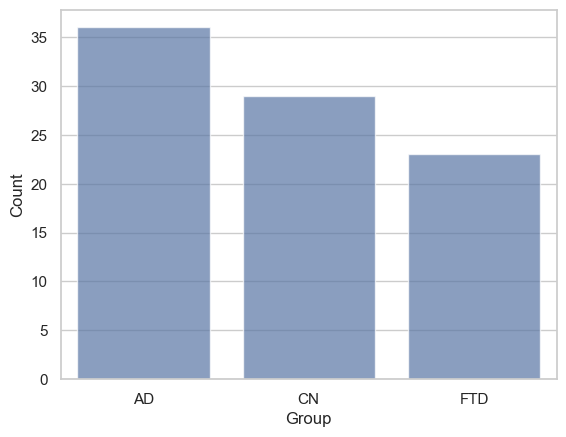

In [12]:
# Plot number of subjects per group
sns.set_theme(style="whitegrid")
labels = ["AD", "CN", "FTD"]
ax = sns.countplot(data=participants, x="Group", alpha=0.7)
ax.set_xticklabels(labels)
# plt.title("Number of subjects per group")
# plt.xlabel("Group")
plt.ylabel("Count")
plt.savefig("group_counts.pdf", dpi=300, bbox_inches="tight")
plt.show()

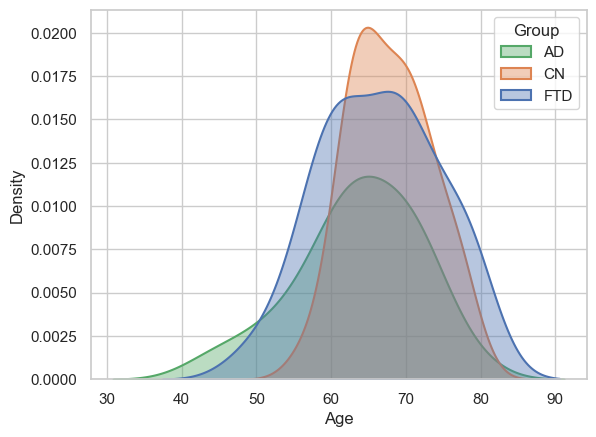

In [7]:
# Plot age density by group
labels = ["AD", "CN", "FTD"]
ax = sns.kdeplot(data=participants, x="Age", hue="Group", fill=True, alpha=0.4, linewidth=1.5)
ax.legend(title="Group", labels=labels)
plt.savefig("age_density.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\xiaox\AppData\Local\Temp\ipykernel_32620\2052412979.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


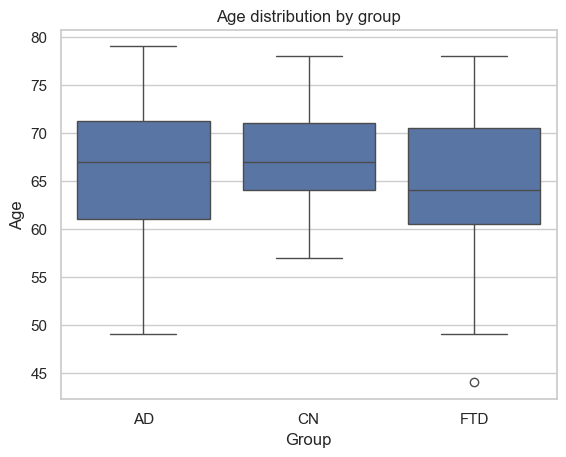

In [8]:
# Boxplot of age distribution by group
labels = ["AD", "CN", "FTD"]
ax = sns.boxplot(data=participants, x="Group", y="Age")
ax.set_xticklabels(labels)
plt.title("Age distribution by group")
plt.savefig("age_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\xiaox\AppData\Local\Temp\ipykernel_32620\3419079818.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


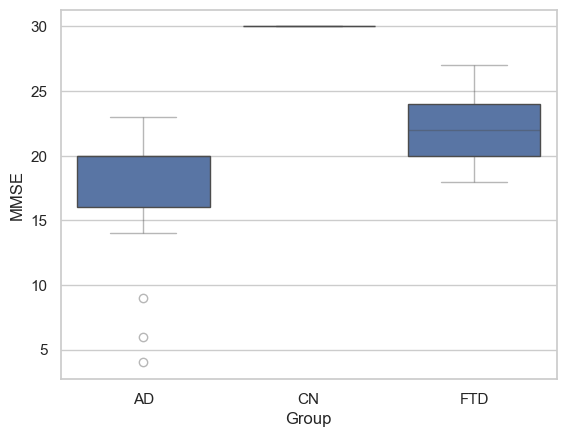

In [9]:
# Boxplot of MMSE distribution by group
labels = ["AD", "CN", "FTD"]
ax = sns.boxplot(data=participants, x="Group", y="MMSE")

for patch in ax.artists:
    patch.set_alpha(0.4) 

for line in ax.lines:
    line.set_alpha(0.4)

ax.set_xticklabels(labels)
# plt.title("MMSE distribution by group")
plt.savefig("mmse_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\xiaox\AppData\Local\Temp\ipykernel_32620\923317769.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


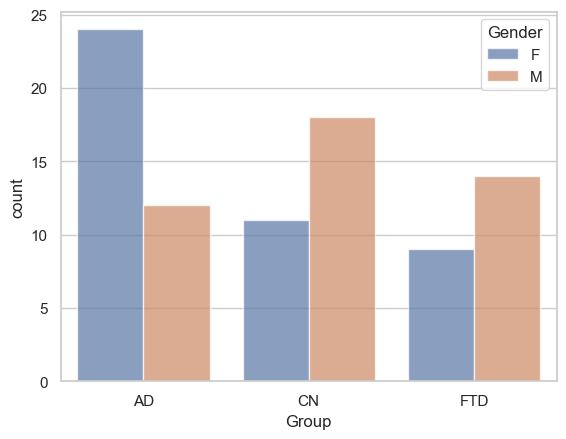

In [10]:
# Plot gender distribution by group
labels = ["AD", "CN", "FTD"]
ax = sns.countplot(data=participants, x="Group", hue="Gender", alpha=0.7)
ax.set_xticklabels(labels)
# plt.title("Gender distribution across groups")
plt.savefig("gender_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
# Extract recording duration from subject data files

# Path to unprocessed data folder
raw_folder = os.path.join(data_folder, "raw")

records = []

for sub in os.listdir(raw_folder):
    # Load JSON metadata file of each subject
    json_path = os.path.join(raw_folder, sub, "eeg", f"{sub}_task-eyesclosed_eeg.json")
    with open(json_path, "r") as f:
        meta = json.load(f)
        duration_sec = meta.get("RecordingDuration")
        duration_min = duration_sec / 60
        records.append({
            "subject": sub,
            "duration_seconds": duration_sec,
            "duration_minutes": duration_min,
        })

duration_df = pd.DataFrame(records)
duration_df

,subject,duration_seconds,duration_minutes
0,sub-001,599.8,9.996667
1,sub-002,793.1,13.218333
2,sub-003,307.1,5.118333
3,sub-004,707.1,11.785000
4,sub-005,804.1,13.401667
...,...,...,...
83,sub-084,652.1,10.868333
84,sub-085,566.1,9.435000
85,sub-086,655.6,10.926667
86,sub-087,606.1,10.101667


In [10]:
# Merge duration info with participants dataframe
meta_df = pd.merge(participants, duration_df, left_on="participant_id", right_on="subject")
meta_df.head()

,participant_id,Gender,Age,Group,MMSE,subject,duration_seconds,duration_minutes
0,sub-001,F,57,A,16,sub-001,599.8,9.996667
1,sub-002,F,78,A,22,sub-002,793.1,13.218333
2,sub-003,M,70,A,14,sub-003,307.1,5.118333
3,sub-004,F,67,A,20,sub-004,707.1,11.785000
4,sub-005,M,70,A,22,sub-005,804.1,13.401667


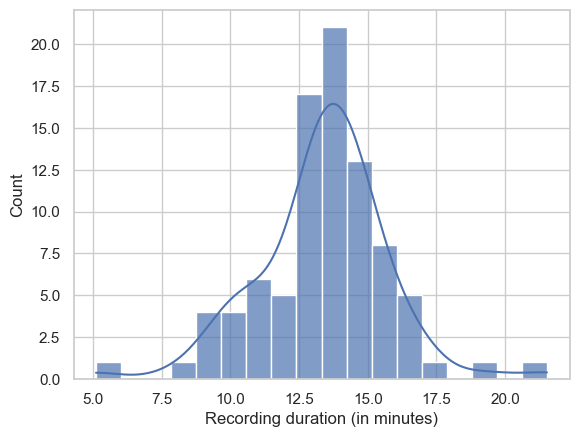

In [13]:
# Overall distribution of recording durations
# plt.figure(figsize=(7,4))
sns.histplot(duration_df["duration_minutes"], kde=True, alpha=0.7)
plt.xlabel("Recording duration (in minutes)")
plt.ylabel("Count")
# plt.title("Distribution of recording durations")
plt.savefig("duration_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()


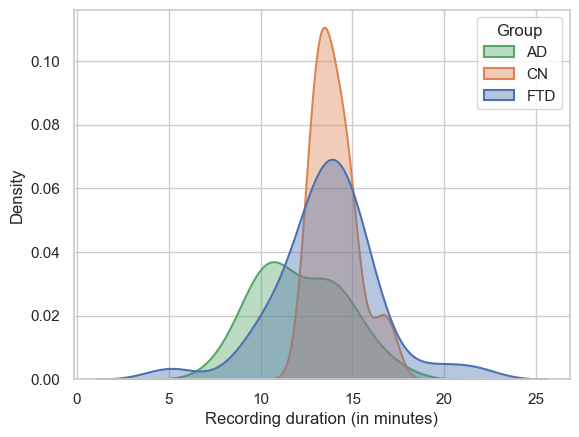

In [ ]:
# Plot recording duration by group
# plt.figure(figsize=(7,4))
labels = ["AD", "CN", "FTD"]
ax = sns.kdeplot(
    data=meta_df,
    x="duration_minutes",
    hue="Group",
    fill=True,
    alpha=0.4, linewidth=1.5
)
plt.xlabel("Recording duration (in minutes)")
# plt.title("Recording duration distribution by group")
ax.legend(title="Group", labels=labels)
plt.savefig("duration_by_group.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\xiaox\AppData\Local\Temp\ipykernel_32620\973026153.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


[Text(0, 0, 'AD'), Text(1, 0, 'CN'), Text(2, 0, 'FTD')]

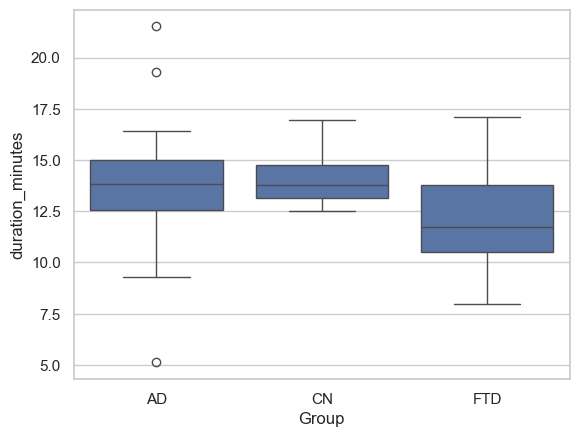

In [15]:
# Plot recording duration by group
ax = sns.boxplot(data=meta_df, x="Group", y="duration_minutes")
ax.set_xticklabels(labels)

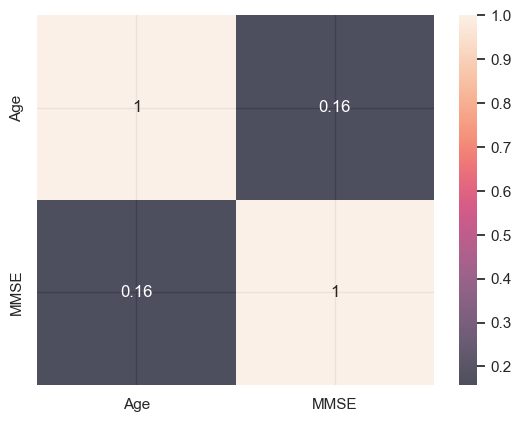

In [16]:
# Correlation heatmap of Age and MMSE
sns.heatmap(meta_df[["Age","MMSE"]].corr(), annot=True, alpha=0.7)
plt.savefig("corr_age_mmse.pdf", dpi=300, bbox_inches="tight")
plt.show()